# 1. OpenAI VLM (GPT) - Basics
This section demonstrates the basic usage of OpenAI's Vision Language Model (VLM) capabilities using GPT-4.1.
We will use the OpenAI API to analyze an image and provide detailed textual insights.

**Reference Material**

- https://developers.openai.com/api/docs/quickstart?language=python
- https://platform.openai.com/docs/guides/text
- https://platform.openai.com/docs/guides/images-vision?api-mode=chat
- https://platform.openai.com/docs/guides/structured-outputs

In [69]:
from openai import OpenAI
from dotenv import load_dotenv  
import base64
import textwrap

# Function to encode the image
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')


load_dotenv()

openai_client = OpenAI()

In [70]:
# Basic call to GPT with a prompt and an image
# Example from: https://developers.openai.com/api/docs/quickstart/?lang=python

response = openai_client.responses.create(
    model="gpt-5",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "What teams are playing in this image?",
                },
                {
                    "type": "input_image",
                    "image_url": "https://api.nga.gov/iiif/a2e6da57-3cd1-4235-b20e-95dcaefed6c8/full/!800,800/0/default.jpg"
                }
            ]
        }
    ]
)

print(response.output_text)

None. This is a portrait painting, not a sports scene with teams playing.


In [71]:
# Path to your image
img = "images/street_scene.jpg"

response = openai_client.responses.create(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "What's in this image?"},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}"
                }
            ],
        }
    ],
)

print(textwrap.fill(response.output_text, width=120))

The image depicts a lively urban scene at a city square or park near a crosswalk. Various individuals are engaged in
different activities: a young person sitting on the ground using a tablet, someone lying down on the pavement, a man
sitting on a bench reading a newspaper, an elderly man in a suit sitting and contemplating, and a woman walking while
looking at her phone. Several pigeons are scattered on the sidewalk. In the background, there are cars and motorcycles
moving through the street, and a man is playing a guitar while walking along the crosswalk. The setting is surrounded by
tall buildings and has a warm, late afternoon light. The overall atmosphere blends everyday city life with a touch of
tranquility and interaction with urban nature.


# 1.1 JSON Schema for Controlled Structured Outputs
In this section, we define a JSON schema for a more controlled and specific model output.
Using this schema, we can ensure the model adheres to predefined data types and structures while describing images.
In this case, we provide the JSON schema directly.

**Reference Material**:
- Data Validation: https://docs.pydantic.dev/latest/
- https://platform.openai.com/docs/guides/structured-outputs

In [72]:
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Literal

client = OpenAI()


class Person(BaseModel):
    position: str
    age: int = Field(ge=0)
    activity: str
    gender: Literal["male", "female", "non-binary", "other", "prefer not to say"]


class ImageExtract(BaseModel):
    numberOfPeople: int = Field(ge=0)
    atmosphere: str
    hourOfTheDay: int = Field(ge=0, le=23)
    people: List[Person]


response = client.responses.parse(
    model="gpt-4.1-mini",
    temperature=0,
    text_format=ImageExtract,
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": "You are a careful observer."
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "Describe the image in detail"},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}"
                },
            ],
        },
    ],
)

result: ImageExtract = response.output_parsed

In [73]:
print(result.model_dump_json(indent=2))

{
  "numberOfPeople": 10,
  "atmosphere": "busy urban street scene with a mix of calm and activity during late afternoon or early evening",
  "hourOfTheDay": 17,
  "people": [
    {
      "position": "sitting on the ground near a flower pot",
      "age": 20,
      "activity": "using a smartphone",
      "gender": "female"
    },
    {
      "position": "lying on the ground near the crosswalk",
      "age": 22,
      "activity": "resting or relaxing",
      "gender": "male"
    },
    {
      "position": "sitting on a bench reading a newspaper",
      "age": 30,
      "activity": "reading",
      "gender": "female"
    },
    {
      "position": "sitting on a bench thinking or resting",
      "age": 65,
      "activity": "thinking or resting",
      "gender": "male"
    },
    {
      "position": "walking on the crosswalk playing guitar",
      "age": 28,
      "activity": "playing guitar",
      "gender": "male"
    },
    {
      "position": "riding a motorcycle on the crosswalk",
  

In [74]:
for person in result.people:
    print(person.position, person.activity, person.age)

sitting on the ground near a flower pot using a smartphone 20
lying on the ground near the crosswalk resting or relaxing 22
sitting on a bench reading a newspaper reading 30
sitting on a bench thinking or resting thinking or resting 65
walking on the crosswalk playing guitar playing guitar 28
riding a motorcycle on the crosswalk riding motorcycle 35
riding a scooter on the crosswalk riding scooter 30
walking on the sidewalk using a smartphone using smartphone 22
inside a taxi car driving 40
inside a taxi car passenger 40


We can then integrate all or part of the extracted information into a new prompt for a follow-up extraction.

In [75]:
# Alert service prompt
class AlertAssessment(BaseModel):
    anyone_in_danger: bool
    alert_hospital: bool
    hospital_type: Literal["none", "child_hospital", "normal_hospital"]
    concise_reason: str
    
alert_sys_prompt = "You are an experienced first-aid paramedic."
alert_prompt = (
    "Given this scene analysis, determine whether anyone might be in danger and "
    "whether a child hospital or a normal hospital should be alerted. "
    "Respond concisely and conservatively. "
    "If the evidence is uncertain, say so.\n\n"
    f"Scene analysis:\n{result.model_dump_json(indent=2)}"
)

In [76]:
alert_response = client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "system",
            "content": [{"type": "input_text", "text": alert_sys_prompt}],
        },
        {
            "role": "user",
            "content": [{"type": "input_text", "text": alert_prompt}],
        },
    ],
    text_format=AlertAssessment,
)

alert_result: AlertAssessment = alert_response.output_parsed

print(alert_result.model_dump_json(indent=2))
print(textwrap.fill(alert_result.concise_reason, width=120))

{
  "anyone_in_danger": false,
  "alert_hospital": false,
  "hospital_type": "none",
  "concise_reason": "No one appears injured or in need of urgent medical assistance; activities and postures are normal for a busy street scene."
}
No one appears injured or in need of urgent medical assistance; activities and postures are normal for a busy street
scene.


In [77]:

# ---- Youngest-person localization models ----

class Box2DResult(BaseModel):
    person_description: str
    estimated_age: int = Field(ge=0)
    box_2d: List[int] = Field(
        description="Normalized [ymin, xmin, ymax, xmax] coordinates in range 0-1000"
    )


youngest_prompt = (
    "Considering this list of people:\n"
    f"{result.model_dump_json(indent=2)}\n\n"
    "Identify the youngest person in the image and return their coordinates. "
    "The box_2d must be [ymin, xmin, ymax, xmax], normalized to 0-1000. "
    "Return only the structured result."
)

youngest_response = client.responses.parse(
    model="gpt-4.1-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": youngest_prompt},
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{encode_image(img)}",
                },
            ],
        }
    ],
    text_format=Box2DResult,
)

youngest_result: Box2DResult = youngest_response.output_parsed

print(youngest_result.model_dump_json(indent=2))

{
  "person_description": "A 20-year-old female sitting on the ground near a flower pot using a smartphone.",
  "estimated_age": 20,
  "box_2d": [
    790,
    90,
    965,
    275
  ]
}


In [78]:
img

'images/street_scene.jpg'

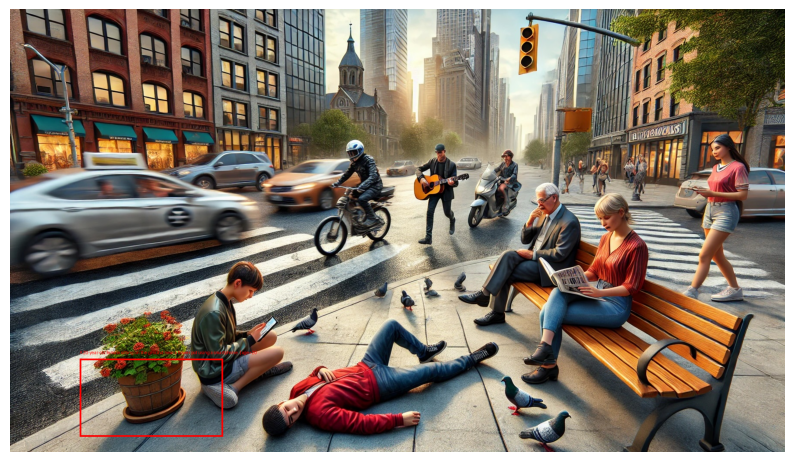

In [79]:
from PIL import ImageDraw, Image
import matplotlib.pyplot as plt

def visualize_detection(img_path, detection):
    img = Image.open(img_path).convert("RGB")
    width, height = img.size
    
    ymin, xmin, ymax, xmax = detection.box_2d

    x1 = int(xmin / 1000 * width)
    y1 = int(ymin / 1000 * height)
    x2 = int(xmax / 1000 * width)
    y2 = int(ymax / 1000 * height)

    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

    label = f"{detection.person_description} | age={detection.estimated_age}"
    draw.text((x1, max(0, y1 - 20)), label, fill="red")

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


visualize_detection(img, youngest_result)

# 2. Google VLM (Gemini)
This section demonstrates the use of Google's Vision Language Model, Gemini.
We explore basic text generation as well as image analysis capabilities and structured outputs.

**Reference Material**:
- https://ai.google.dev/gemini-api/docs/quickstart
- https://ai.google.dev/gemini-api/docs/text-generation
- https://ai.google.dev/gemini-api/docs/image-understanding
- https://ai.google.dev/gemini-api/docs/structured-output?example=recipe

In [80]:
from dotenv import load_dotenv
from google import genai
from PIL import Image
import textwrap

import json


load_dotenv()
client = genai.Client()

# Path to your image
img = "images/street_scene.jpg"

Basic call:

In [81]:
response = client.models.generate_content(
    model="gemini-2.5-flash", contents="Explain how AI works to a 90-year-old in a few words."
)

print(textwrap.fill(response.text, width=120))

It's like teaching a computer to learn from millions of examples, then it uses that knowledge to figure things out and
help you.


And with images:

In [82]:
im = Image.open(img)

response = client.models.generate_content(model="gemini-2.5-flash",
                                          contents=[im, "Describe the scene in detail.\n"],
                                          )

print(textwrap.fill(response.text, width=120))

This image captures a vibrant and bustling city street scene, likely in a metropolitan area, with a mix of modern
skyscrapers and older brick buildings under a clear sky, possibly during late afternoon or early morning given the long
shadows and golden light.  In the immediate **foreground**, a paved sidewalk separates the viewer from a busy street. *
On the left, a large wooden barrel planter overflows with vibrant red and orange flowers, adding a touch of nature to
the urban setting. *   To its right, a young boy with short dark hair, wearing a green jacket and grey shorts, sits
cross-legged on the pavement, engrossed in a tablet or phone he holds in his hands. *   Directly beside him, a young man
in a red hoodie and blue jeans is lying flat on his back on the concrete, looking up at the sky. He appears relaxed or
contemplative rather than distressed. *   Several pigeons are scattered across the sidewalk in this area, pecking at the
ground or walking around the people.  Further to th

We can also extract structured output (Gemini generally prefers Pydantic syntax).
Let's see how it behaves with a schema like before. See limitations: https://ai.google.dev/gemini-api/docs/structured-output?example=recipe

In [83]:
from pydantic import BaseModel, Field
from typing import List, Literal

class Person(BaseModel):
    position: str
    age: int = Field(ge=0)
    activity: str
    gender: Literal["male", "female", "non-binary", "other", "prefer not to say"]

class ImageExtract(BaseModel):
    numberOfPeople: int = Field(ge=0)
    atmosphere: str
    hourOfTheDay: int = Field(ge=0, le=23)
    people: List[Person]
    
    
json_schema = ImageExtract.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": json_schema
}

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        im,
        "Describe the scene in detail and follow the given JSON schema exactly."
    ],
    config=config
)

print(response.text)

{
  "numberOfPeople": 8,
  "atmosphere": "A bustling urban street scene on a sunny day, with a mix of pedestrians and vehicles, featuring people engaged in various activities on a sidewalk and crossing a street.",
  "hourOfTheDay": 17,
  "people": [
    {
      "position": "Sitting on a wooden bench on the right side of the sidewalk",
      "age": 68,
      "activity": "Resting, with one hand on his chin, observing the surroundings",
      "gender": "male"
    },
    {
      "position": "Sitting on a wooden bench next to the elderly man",
      "age": 45,
      "activity": "Reading a newspaper",
      "gender": "female"
    },
    {
      "position": "Walking on the sidewalk towards the right, near the crosswalk",
      "age": 24,
      "activity": "Walking and holding a plate with a snack or small meal",
      "gender": "female"
    },
    {
      "position": "Sitting cross-legged on the sidewalk to the left of the bench, near a potted plant",
      "age": 15,
      "activity": "Looki

In [84]:
import json

data = json.loads(response.text)

result = ImageExtract(**data)

print(result)
print(result.people[0].activity)

numberOfPeople=8 atmosphere='A bustling urban street scene on a sunny day, with a mix of pedestrians and vehicles, featuring people engaged in various activities on a sidewalk and crossing a street.' hourOfTheDay=17 people=[Person(position='Sitting on a wooden bench on the right side of the sidewalk', age=68, activity='Resting, with one hand on his chin, observing the surroundings', gender='male'), Person(position='Sitting on a wooden bench next to the elderly man', age=45, activity='Reading a newspaper', gender='female'), Person(position='Walking on the sidewalk towards the right, near the crosswalk', age=24, activity='Walking and holding a plate with a snack or small meal', gender='female'), Person(position='Sitting cross-legged on the sidewalk to the left of the bench, near a potted plant', age=15, activity='Looking at or interacting with a digital tablet or phone', gender='male'), Person(position='Lying on his back on the sidewalk between the sitting boy and the crosswalk', age=22,

Does it match your schema?

Let's use Gemini to detect an object in the image and return its coordinates:

In [85]:
from pydantic import BaseModel, Field
from typing import List

class Box2DResult(BaseModel):
    person_description: str
    estimated_age: int = Field(ge=0)
    box_2d: List[int] = Field(
        description="Normalized [ymin, xmin, ymax, xmax] coordinates in range 0-1000"
    )

import json

schema = Box2DResult.model_json_schema()

config = {
    "response_mime_type": "application/json",
    "response_json_schema": schema
}

youngest_prompt = (
    "Considering this list of people:\n"
    f"{result.model_dump_json(indent=2)}\n\n"
    "Identify the youngest person in the image and return their coordinates. "
    "The box_2d must be [ymin, xmin, ymax, xmax], normalized to 0-1000. "
    "Return only the structured result."
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[img, youngest_prompt],
    config=config
)

data = json.loads(response.text)

result = Box2DResult(**data)

print(result)

person_description='Sitting cross-legged on the sidewalk to the left of the bench, near a potted plant, looking at or interacting with a digital tablet or phone' estimated_age=15 box_2d=[650, 200, 880, 350]


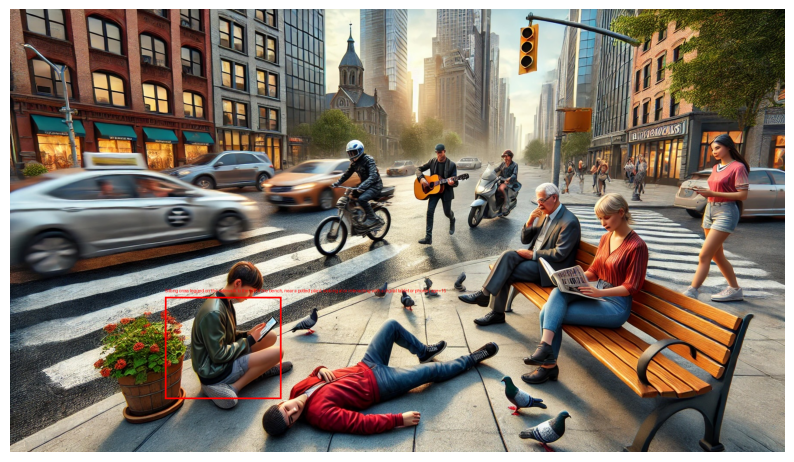

In [86]:
visualize_detection(img, result)

Gemini 2+ was trained specifically for object detection and segmentation tasks.

More details: https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb

## 3. Extract Structured Information from a Handwritten Note - GPT & Gemini

Let's extract structured information from a handwritten note (e.g., `prescription1.jpg`) using both models.

Consider the file: `/images/prescription1.jpg`.
Take a look at it.

### JSON Schema
Let's define a JSON schema for the extraction task:

In [87]:
json_schema_prescription = {
 "name": "prescription_extract",
"schema": {
  "type": "object",
  "properties": {
    "doctor_name": { "type": "string" },
    "patient_name": { "type": "string" },
    "patient_dob": { "type": "string" },
    "meds": {
      "type": "array",
      "items": {
        "type": "object",
        "properties": {
          "name": { "type": "string" },
          "dose": { "type": "string" },
          "frequency": { "type": "string" },
          "instructions": { "type": "string" }
        },
        "required": ["name"]
      }
    },
    "signature": { "type": "boolean" }
  },
  "required": ["doctor_name", "patient_name", "meds"]
}}

## TODO
- Extract once with OpenAI and once with Google Gemini using Pydantic validation (https://docs.pydantic.dev/latest/).

Extract structured information using Gemini:

In [88]:
im = Image.open("images/prescription1.jpg")
#TODO

Now let's do the same with GPT.

In [89]:
im = "images/prescription1.jpg"
#TODO


Any differences between the Gemini and OpenAI outputs?